In [1]:
# Cell 1: Import all libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Load the cleaned data
df = pd.read_csv("../data/processed/cleaned_data.csv")
print("✅ Data loaded!")
print(f"Shape: {df.shape}")
df.head()

✅ Data loaded!
Shape: (145460, 21)


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,13.4,22.9,0.6,5.468232,7.611178,14,44.0,14,15,20.0,...,71.0,22.0,1007.7,1007.1,8.000000,4.50993,16.9,21.8,0.0,0
1,7.4,25.1,0.0,5.468232,7.611178,15,44.0,6,16,4.0,...,44.0,25.0,1010.6,1007.8,4.447461,4.50993,17.2,24.3,0.0,0
2,12.9,25.7,0.0,5.468232,7.611178,16,46.0,14,16,19.0,...,38.0,30.0,1007.6,1008.7,4.447461,2.00000,21.0,23.2,0.0,0
3,9.2,28.0,0.0,5.468232,7.611178,4,24.0,9,0,11.0,...,45.0,16.0,1017.6,1012.8,4.447461,4.50993,18.1,26.5,0.0,0
4,17.5,32.3,1.0,5.468232,7.611178,14,41.0,1,7,7.0,...,82.0,33.0,1010.8,1006.0,7.000000,8.00000,17.8,29.7,0.0,0


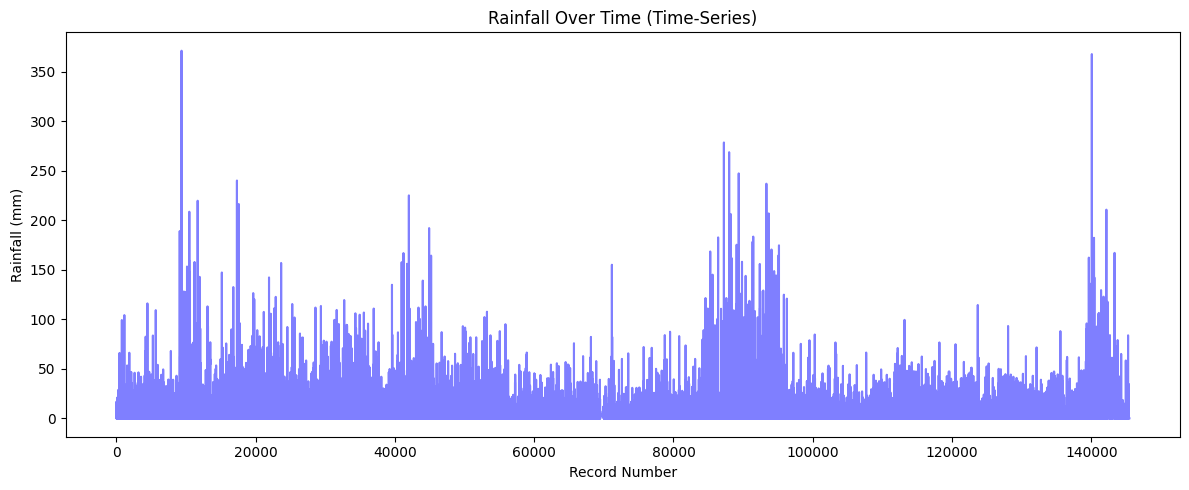

In [2]:
# Cell 2: Time-series - Rainfall distribution by month
plt.figure(figsize=(12, 5))
df["Rainfall"].plot(kind="line", color="blue", alpha=0.5)
plt.title("Rainfall Over Time (Time-Series)")
plt.xlabel("Record Number")
plt.ylabel("Rainfall (mm)")
plt.tight_layout()
plt.show()

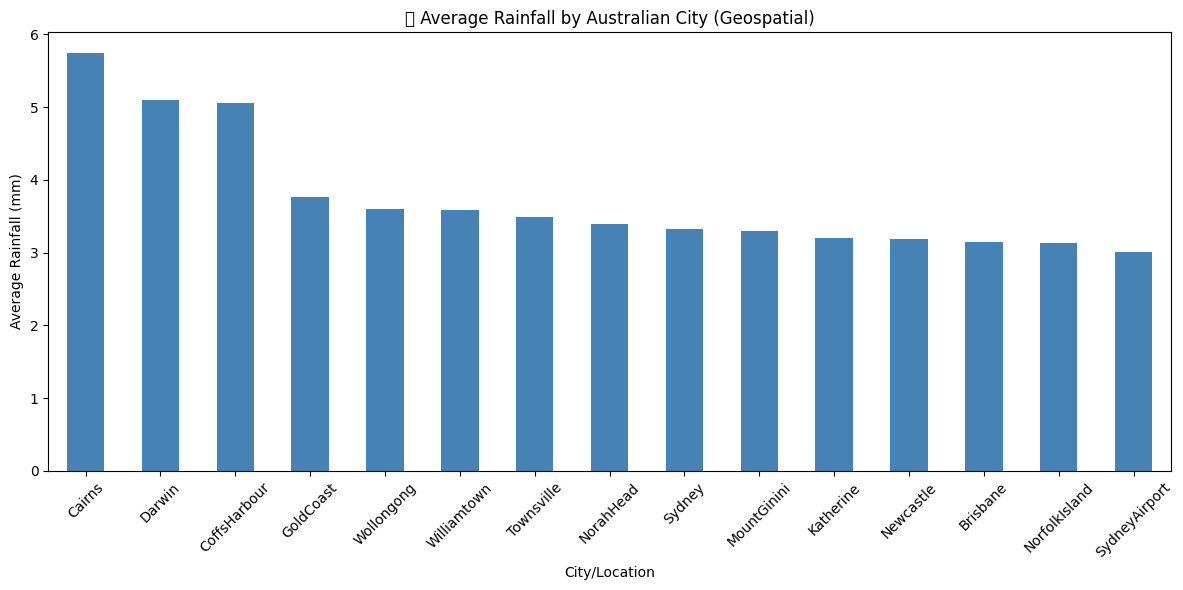

In [3]:
# Cell 3: Geospatial - Average rainfall by location
# Load original raw data which has Location column
raw = pd.read_csv("../data/raw/weatherAUS.csv")
city_rain = raw.groupby("Location")["Rainfall"].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
city_rain.plot(kind="bar", color="steelblue")
plt.title("🗺️ Average Rainfall by Australian City (Geospatial)")
plt.xlabel("City/Location")
plt.ylabel("Average Rainfall (mm)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

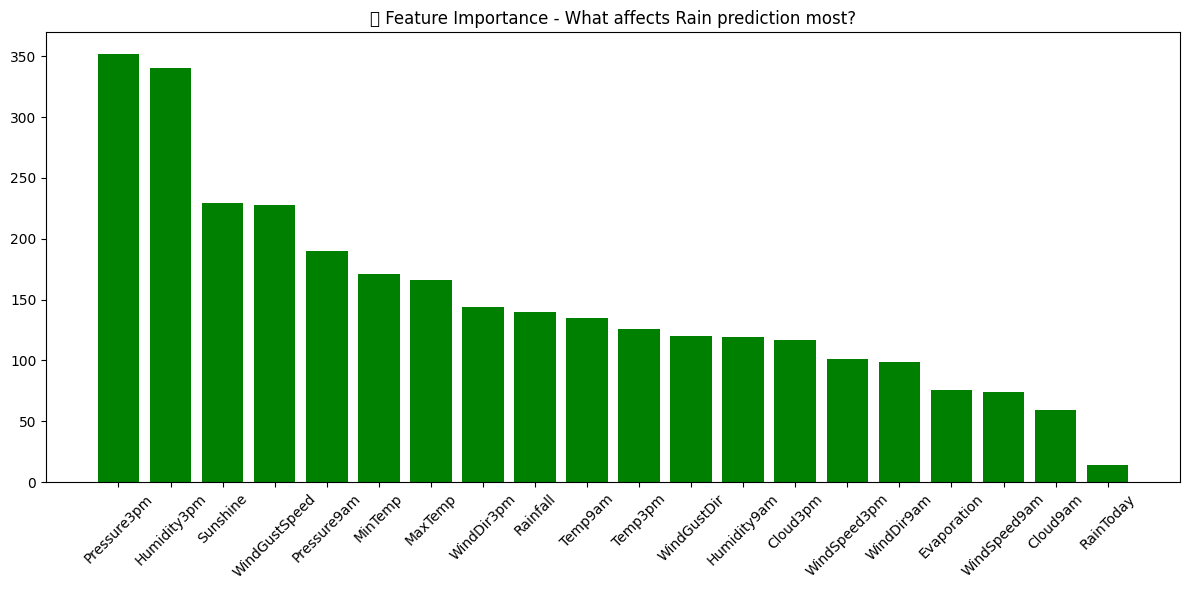

In [4]:
# Cell 4: Feature importance from our trained model
import joblib
import numpy as np

model = joblib.load("../models/rainfall_model.pkl")
features = ['MinTemp','MaxTemp','Rainfall','Evaporation','Sunshine',
            'WindGustDir','WindGustSpeed','WindDir9am','WindDir3pm',
            'WindSpeed9am','WindSpeed3pm','Humidity9am','Humidity3pm',
            'Pressure9am','Pressure3pm','Cloud9am','Cloud3pm',
            'Temp9am','Temp3pm','RainToday']

importance = model.feature_importances_
indices = np.argsort(importance)[::-1]

plt.figure(figsize=(12, 6))
plt.bar(range(len(features)), importance[indices], color="green")
plt.xticks(range(len(features)), [features[i] for i in indices], rotation=45)
plt.title("🌟 Feature Importance - What affects Rain prediction most?")
plt.tight_layout()
plt.show()

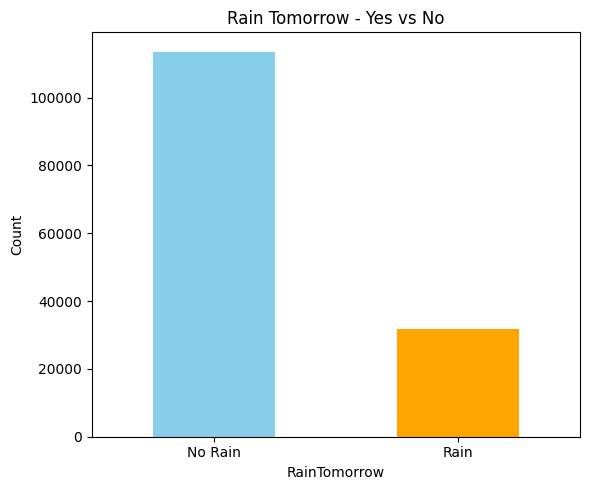

In [5]:
# Cell 5: Rain tomorrow - Yes vs No count
plt.figure(figsize=(6, 5))
df["RainTomorrow"].value_counts().plot(kind="bar", color=["skyblue","orange"])
plt.title("Rain Tomorrow - Yes vs No")
plt.xticks([0, 1], ["No Rain", "Rain"], rotation=0)
plt.ylabel("Count")
plt.tight_layout()
plt.show()